In [ ]:
from xspec import *
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
import numpy as np

In [ ]:
Xset.abund = "feld"      # Solar abundance standard (Feldman 1992)
Xset.xsect = "bcmc"      # Cross-sections
Fit.statMethod = "cstat" # Use Cash statistics for potential low counts
Fit.nIterations = 50
Xset.chatter = 0
Xset.logChatter = 0

In [ ]:
Plot.device = "/null"
Fit.query = "yes"

# REPLACE with your actual file path
filename = "/mnt/OM02/Projects/AL1/SolARIS/HEL1OS/2026/HLS_20260630_121027_42569sec_lev1_V111/cdte/hel1os_cdte_spectra_cdte1.fits" 

# Extract Time and Number of Intervals
with fits.open(filename) as hdul:
    time_data = hdul[1].data['TSTART']  # Get UTC time column [2, 3]
    total_intervals = len(time_data)

In [ ]:
results_thermal = []

for i in range(1, total_intervals + 1):
    AllData.clear()
    
    # Load row i of the Type-II file
    s = Spectrum(f"{filename}{{{i}}}")
    s.response = "/mnt/OM02/Projects/AL1/SolARIS/HEL1OS/2026/HLS_20260630_121027_42569sec_lev1_V111/cdte/hel1os_cdte_srf_v03.fits"
    s.response.arf = "/mnt/OM02/Projects/AL1/SolARIS/HEL1OS/2026/HLS_20260630_121027_42569sec_lev1_V111/cdte/hel1os_cdte_arf_v03.fits"
    
    # Ignore energies outside the valid range
    s.ignore("0.0-9.5, 40.0-**")
    
    # CRITICAL CHECK: If this specific time interval has 0 valid counts, XSPEC will freeze everything.
    # We check if there are noticed channels before fitting.
    if s.noticed == 0:
        print(f"Skipping interval {i}: No noticed data channels after ignore.")
        continue

    # Model: Absorption * Thermal Bremsstrahlung
    m = Model("phabs*bremss")
    
    # --- PYXSPEC PARAMETER FIXES ---
    # 1. Provide safe initial guesses so it doesn't start at a boundary
    m.phabs.nH = 0.1
    m.bremss.kT = 5.0      # Set a reasonable starting temperature (e.g., 5 keV)
    m.bremss.norm = 1.0    # Set a baseline starting norm instead of leaving it default
    
    # 2. Explicitly THAW the parameters so XSPEC is forced to vary them
    m.phabs.nH.frozen = False
    m.bremss.kT.frozen = False
    m.bremss.norm.frozen = False
    # -------------------------------
    
    try:
        Fit.perform()
        
        # Extract results (.values returns a list: [value, error])
        kt = m.bremss.kT.values[0]       
        norm = m.bremss.norm.values[0]   
        
        results_thermal.append({
            "TIME": time_data[i-1],
            "TEMPERATURE": kt,
            "EM_NORM": norm
        })
    except Exception as e:
        print(f"Fit failed at interval {i} due to: {e}")
        # Append NaNs so your dataframe timeline stays perfectly aligned
        results_thermal.append({
            "TIME": time_data[i-1],
            "TEMPERATURE": np.nan,
            "EM_NORM": np.nan
        })
        
    print(i)

df_thermal = pd.DataFrame(results_thermal)

In [ ]:
# REPLACE with CZT filename
czt_file = "/mnt/OM02/Projects/AL1/SolARIS/HEL1OS/2026/HLS_20260630_121027_42569sec_lev1_V111/czt/hel1os_czt_spectra_czt1.fits"
results_index = []

for i in range(1, total_intervals + 1):
    AllData.clear()
    s = Spectrum(f"{czt_file}{{{i}}}")
    s.response = "/mnt/OM02/Projects/AL1/SolARIS/HEL1OS/2026/HLS_20260630_121027_42569sec_lev1_V111/czt/hel1os_czt_srf_v03.fits"
    s.response.arf = "/mnt/OM02/Projects/AL1/SolARIS/HEL1OS/2026/HLS_20260630_121027_42569sec_lev1_V111/czt/hel1os_czt_arf_v03.fits"
    
    # CZT recommended spectral range is >35 keV [6, 7]
    s.ignore("0.0-35.0, 150.0-**")
    
    # Model: Single Power Law [12]
    m = Model("phabs*powerlaw")
    Fit.perform()
    
    gamma = m.powerlaw.PhoIndex.values # The Spectral Index [13, 14]
    
    results_index.append({
        "TIME": time_data[i-1],
        "SPECTRAL_INDEX": gamma
    })
    print(i)

df_index = pd.DataFrame(results_index)

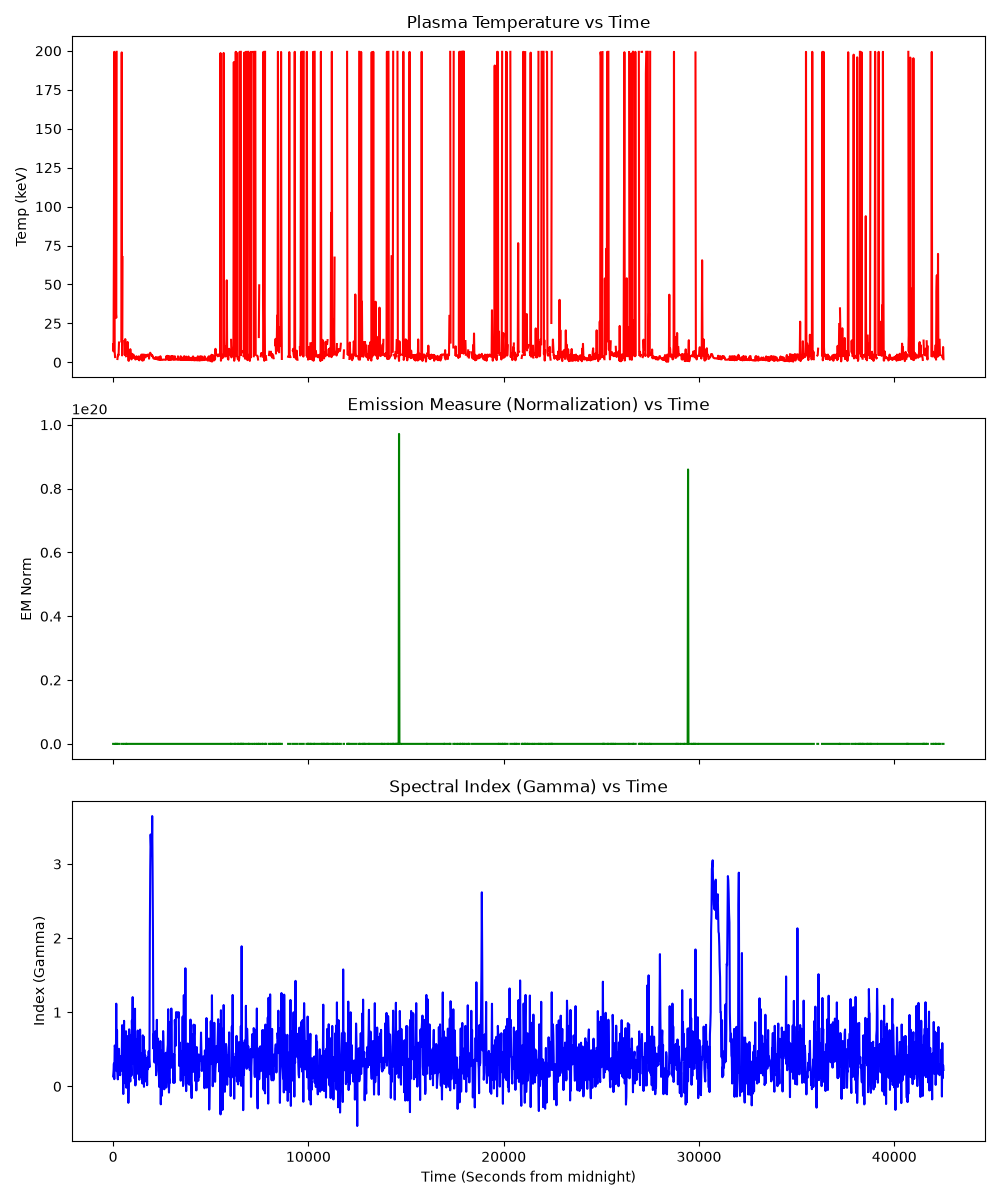

In [29]:
df = pd.merge(df_index, df_thermal, on='TIME', how='inner')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1. Temperature vs Time
ax1.plot(df['TIME'], df['TEMPERATURE'], color='red')
ax1.set_ylabel("Temp (keV)")
ax1.set_title("Plasma Temperature vs Time")

# 2. Emission Measure (Norm) vs Time
ax2.plot(df['TIME'], df['EM_NORM'], color='green')
ax2.set_ylabel("EM Norm")
ax2.set_title("Emission Measure (Normalization) vs Time")

# 3. Spectral Index vs Time
ax3.plot(df['TIME'], df['SPECTRAL_INDEX'].str[0], color='blue')
ax3.set_ylabel("Index (Gamma)")
ax3.set_xlabel("Time (Seconds from midnight)")
ax3.set_title("Spectral Index (Gamma) vs Time")

plt.tight_layout()
plt.show()

# df_thermal